# 1. Imports and Paths

In [2]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "data" / "fx_fintech_product_analytics.db"

DB_PATH

WindowsPath('c:/Users/Anwar/Documents/Work duty/switchwon/data/fx_fintech_product_analytics.db')

# 2. Connect and Check Table Columns

In [3]:
conn = sqlite3.connect(DB_PATH)

columns = pd.read_sql_query("""
    PRAGMA table_info(modeling_user_month_snapshots);
""", conn)

columns

,cid,name,type,notnull,dflt_value,pk
0,0,user_id,TEXT,0,None,0
1,1,observation_date,,0,None,0
2,2,recency_days,INT,0,None,0
3,3,transactions_90d,,0,None,0
4,4,transactions_all,,0,None,0
5,5,total_volume_90d,,0,None,0
6,6,failed_ratio_90d,,0,None,0
7,7,target_repeat_30d,,0,None,0


# 3. Table Summary

In [4]:
summary = pd.read_sql_query("""
    SELECT
        COUNT(*) AS snapshot_rows,
        COUNT(DISTINCT user_id) AS users,
        MIN(observation_date) AS min_observation_date,
        MAX(observation_date) AS max_observation_date,
        SUM(target_repeat_30d) AS positive_targets,
        ROUND(
            100.0 * SUM(target_repeat_30d) / COUNT(*),
            2
        ) AS positive_target_rate,
        ROUND(AVG(recency_days), 2) AS avg_recency_days,
        ROUND(AVG(transactions_90d), 2) AS avg_transactions_90d,
        ROUND(AVG(failed_ratio_90d), 4) AS avg_failed_ratio_90d
    FROM modeling_user_month_snapshots;
""", conn)

summary

,snapshot_rows,users,min_observation_date,max_observation_date,positive_targets,positive_target_rate,avg_recency_days,avg_transactions_90d,avg_failed_ratio_90d
0,206376,23387,2024-06-30,2025-11-30,84459,40.92,63.51,2.28,0.0526


# 4. Preview Rows

In [5]:
sample = pd.read_sql_query("""
    SELECT *
    FROM modeling_user_month_snapshots
    LIMIT 10;
""", conn)

sample

,user_id,observation_date,recency_days,transactions_90d,transactions_all,total_volume_90d,failed_ratio_90d,target_repeat_30d
0,USR000000,2024-12-31,1,8,8,31369961,0.111111,1
1,USR000000,2025-01-31,3,10,10,35737750,0.166667,0
2,USR000000,2025-02-28,31,10,10,35737750,0.090909,1
3,USR000000,2025-03-31,6,5,13,13782502,0.285714,1
4,USR000000,2025-04-30,22,4,14,10477657,0.333333,1
5,USR000000,2025-05-31,5,9,19,28791531,0.181818,1
6,USR000000,2025-06-30,7,11,24,44935596,0.153846,1
7,USR000000,2025-07-31,3,17,31,56707956,0.105263,1
8,USR000000,2025-08-31,13,12,32,41672729,0.142857,1
9,USR000000,2025-09-30,1,12,36,33550219,0.076923,1


# 5. Missing Values

In [6]:
df = pd.read_sql_query("""
    SELECT *
    FROM modeling_user_month_snapshots;
""", conn)

conn.close()

missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_summary["missing_rate"] = missing_summary["missing_count"] / len(df)

missing_summary.sort_values("missing_count", ascending=False)

,column,missing_count,missing_rate
0,user_id,0,0.0
1,observation_date,0,0.0
2,recency_days,0,0.0
3,transactions_90d,0,0.0
4,transactions_all,0,0.0
5,total_volume_90d,0,0.0
6,failed_ratio_90d,0,0.0
7,target_repeat_30d,0,0.0


# 6. Target Balance

In [7]:
target_balance = (
    df["target_repeat_30d"]
    .value_counts(normalize=False)
    .rename_axis("target_repeat_30d")
    .reset_index(name="rows")
)

target_balance["share"] = target_balance["rows"] / target_balance["rows"].sum()

target_balance

,target_repeat_30d,rows,share
0,0,121917,0.590752
1,1,84459,0.409248


# 7. Date Coverage

In [8]:
df["observation_date"] = pd.to_datetime(df["observation_date"])

monthly_rows = (
    df.groupby(df["observation_date"].dt.to_period("M"))
    .agg(
        rows=("user_id", "count"),
        users=("user_id", "nunique"),
        positive_rate=("target_repeat_30d", "mean"),
    )
    .reset_index()
)

monthly_rows["observation_month"] = monthly_rows["observation_date"].astype(str)
monthly_rows = monthly_rows.drop(columns="observation_date")

monthly_rows.head(), monthly_rows.tail()

(   rows  users  positive_rate observation_month
 0  2441   2441       0.369930           2024-06
 1  3324   3324       0.377557           2024-07
 2  4178   4178       0.378411           2024-08
 3  4944   4944       0.369943           2024-09
 4  5803   5803       0.371360           2024-10,
      rows  users  positive_rate observation_month
 13  16844  16844       0.423296           2025-07
 14  18424  18424       0.428680           2025-08
 15  19946  19946       0.433871           2025-09
 16  21509  21509       0.434097           2025-10
 17  23387  23387       0.438834           2025-11)

# 8. Inspect Columns

In [9]:
df.columns.tolist()

['user_id',
 'observation_date',
 'recency_days',
 'transactions_90d',
 'transactions_all',
 'total_volume_90d',
 'failed_ratio_90d',
 'target_repeat_30d']

# 9. Basic Modeling Dataset

In [10]:
target_col = "target_repeat_30d"

id_cols = [
    "user_id",
    "observation_date",
]

feature_cols = [
    col for col in df.columns
    if col not in id_cols + [target_col]
]

feature_cols

['recency_days',
 'transactions_90d',
 'transactions_all',
 'total_volume_90d',
 'failed_ratio_90d']

# 10. Check Feature Types

In [11]:
df[feature_cols].dtypes.sort_values()

recency_days          int64
transactions_90d      int64
transactions_all      int64
total_volume_90d      int64
failed_ratio_90d    float64
dtype: object

# 11. Time-Based Train/Test Split

In [12]:
df = df.sort_values("observation_date").copy()

cutoff_date = df["observation_date"].quantile(0.8)

train_df = df[df["observation_date"] <= cutoff_date].copy()
test_df = df[df["observation_date"] > cutoff_date].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Cutoff date:", cutoff_date)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target rate:", y_train.mean())
print("Test target rate:", y_test.mean())

Cutoff date: 2025-10-31 00:00:00
Train shape: (182989, 5)
Test shape: (23387, 5)
Train target rate: 0.40546699528386954
Test target rate: 0.43883354000085517


# 12. Missing Value Check for Selected Features

In [13]:
missing_features = (
    X_train.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)

missing_features["missing_rate"] = missing_features["missing_count"] / len(X_train)
missing_features.sort_values("missing_count", ascending=False).head(20)

,feature,missing_count,missing_rate
0,recency_days,0,0.0
1,transactions_90d,0,0.0
2,transactions_all,0,0.0
3,total_volume_90d,0,0.0
4,failed_ratio_90d,0,0.0


# 13. Rebuild Split with Explicit Cutoff

In [14]:
target_col = "target_repeat_30d"

feature_cols = [
    "recency_days",
    "transactions_90d",
    "transactions_all",
    "total_volume_90d",
    "failed_ratio_90d",
]

cutoff_date = pd.Timestamp("2025-10-31")

train_df = df[df["observation_date"] <= cutoff_date].copy()
test_df = df[df["observation_date"] > cutoff_date].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target rate:", round(y_train.mean(), 4))
print("Test target rate:", round(y_test.mean(), 4))

Train shape: (182989, 5)
Test shape: (23387, 5)
Train target rate: 0.4055
Test target rate: 0.4388


# 14. Baseline Model - Majority Class

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_pred = np.zeros(len(y_test))

baseline_metrics = {
    "model": "Majority class baseline",
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
    "roc_auc": 0.5,
}

baseline_metrics

{'model': 'Majority class baseline',
 'accuracy': 0.5611664599991448,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5}

# 15. Logistic Regression

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

logreg_model.fit(X_train, y_train)

logreg_pred = logreg_model.predict(X_test)
logreg_proba = logreg_model.predict_proba(X_test)[:, 1]

logreg_metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, logreg_pred),
    "precision": precision_score(y_test, logreg_pred),
    "recall": recall_score(y_test, logreg_pred),
    "f1": f1_score(y_test, logreg_pred),
    "roc_auc": roc_auc_score(y_test, logreg_proba),
}

logreg_metrics

{'model': 'Logistic Regression',
 'accuracy': 0.7144567494762047,
 'precision': 0.6574993410069414,
 'recall': 0.7291240378057098,
 'f1': 0.6914618369987063,
 'roc_auc': 0.7987036490438619}

# 16. Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_metrics = {
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred),
    "recall": recall_score(y_test, rf_pred),
    "f1": f1_score(y_test, rf_pred),
    "roc_auc": roc_auc_score(y_test, rf_proba),
}

rf_metrics

{'model': 'Random Forest',
 'accuracy': 0.7280968059178176,
 'precision': 0.6731417420613802,
 'recall': 0.739452401831823,
 'f1': 0.7047406788317778,
 'roc_auc': 0.8089721318355}

# 18. Gradient Boosting Model

In [21]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = {
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, xgb_pred),
    "precision": precision_score(y_test, xgb_pred),
    "recall": recall_score(y_test, xgb_pred),
    "f1": f1_score(y_test, xgb_pred),
    "roc_auc": roc_auc_score(y_test, xgb_proba),
}

xgb_metrics

{'model': 'XGBoost',
 'accuracy': 0.7300637106084576,
 'precision': 0.6742852100247088,
 'recall': 0.7445191464484069,
 'f1': 0.7076638110673767,
 'roc_auc': 0.8097878619197163}

# Compare Models

In [23]:
model_metrics = pd.DataFrame([
    baseline_metrics,
    logreg_metrics,
    rf_metrics,
    xgb_metrics,
])

model_metrics.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
3,XGBoost,0.730064,0.674285,0.744519,0.707664,0.809788
2,Random Forest,0.728097,0.673142,0.739452,0.704741,0.808972
1,Logistic Regression,0.714457,0.657499,0.729124,0.691462,0.798704
0,Majority class baseline,0.561166,0.000000,0.000000,0.000000,0.500000


# 20. Confusion Matrix

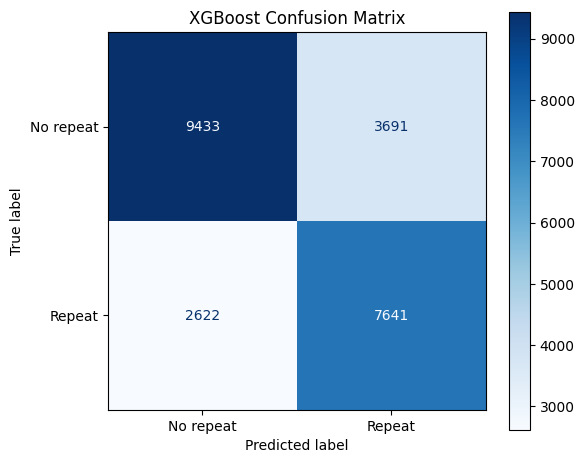

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["No repeat", "Repeat"],
    cmap="Blues",
    ax=ax,
)

ax.set_title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

# 21. Classification Report

In [25]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    xgb_pred,
    target_names=["No repeat", "Repeat"],
    output_dict=True,
)

classification_report_df = pd.DataFrame(report).T

classification_report_df

,precision,recall,f1-score,support
No repeat,0.782497,0.718760,0.749275,13124.000000
Repeat,0.674285,0.744519,0.707664,10263.000000
accuracy,0.730064,0.730064,0.730064,0.730064
macro avg,0.728391,0.731639,0.728470,23387.000000
weighted avg,0.735010,0.730064,0.731015,23387.000000


# 24. Feature Importance

In [26]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
1,transactions_90d,0.529590
3,total_volume_90d,0.208887
0,recency_days,0.115739
2,transactions_all,0.083349
4,failed_ratio_90d,0.062436


XGBoost is selected as the final model because it provides the strongest F1 score while maintaining high recall, making it useful for identifying users likely to repeat exchange activity in the next 30 days.